# Griffiths Ch. 6 — Magnetic Fields in Matter

The magnetic mirror of Ch. 4. Matter magnetizes: atomic current loops align into a magnetization
$\mathbf M$, which shows up as **bound currents** ($\mathbf K_b=\mathbf M\times\hat n$,
$\mathbf J_b=\nabla\times\mathbf M$). Bookkeeping the free current separately gives the **auxiliary
field** $\mathbf H=\mathbf B/\mu_0-\mathbf M$ with $\nabla\times\mathbf H=\mathbf J_{\rm free}$, and
for linear media one constant does it all: $\mu_r=1+\chi_m$.

The dictionary with dielectrics is exact:

| electric (Ch. 4) | magnetic (Ch. 6) |
|---|---|
| polarization $\mathbf P$ | magnetization $\mathbf M$ |
| $\sigma_b=\mathbf P\cdot\hat n$, $\rho_b=-\nabla\cdot\mathbf P$ | $\mathbf K_b=\mathbf M\times\hat n$, $\mathbf J_b=\nabla\times\mathbf M$ |
| $\mathbf D=\epsilon_0\mathbf E+\mathbf P$ | $\mathbf H=\mathbf B/\mu_0-\mathbf M$ |
| $\epsilon_r=1+\chi_e$ | $\mu_r=1+\chi_m$ |

But with one twist: $\mathbf H$ behaves like $\mathbf E$ (reduced inside), while $\mathbf B$ is
*enhanced* — matter pulls magnetic flux in. Engine: `griffiths.magnetic_matter`.

In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import magnetic_matter as mm
from griffiths import magnetostatics as mag

sp.init_printing(use_latex="mathjax")
M, chi, B0 = sp.symbols("M chi_m B_0", positive=True)
mu_r = sp.Symbol("mu_r", positive=True); theta = sp.Symbol("theta")
print("griffiths.magnetic_matter loaded")

griffiths.magnetic_matter loaded


## §1 Magnetization and bound currents

A magnetized object carries surface and (if $\mathbf M$ varies) volume currents:
$\mathbf K_b=\mathbf M\times\hat n$, $\mathbf J_b=\nabla\times\mathbf M$. Uniform $\mathbf M$ leaves
only a surface current — the magnetic dual of bound surface charge.

In [4]:
display(Math(r"|\mathbf K_b| = |\mathbf M\times\hat n| = " + sp.latex(mm.bound_surface_current(M, theta))
             + r"\quad(\mathbf M \parallel \hat z\text{ on a sphere})"))
x, y, z = gr.x, gr.y, gr.z
M_uniform = sp.Matrix([0, 0, M])
display(Math(r"\mathbf J_b = \nabla\times\mathbf M = " + sp.latex(mm.bound_volume_current(M_uniform).T)
             + r"\quad(\text{uniform }\mathbf M)"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §2 The auxiliary field H

$\mathbf H\equiv\mathbf B/\mu_0-\mathbf M$ is built so that its curl sees only the *free* current:
$\nabla\times\mathbf H=\mathbf J_{\rm free}$ (Ampere for H). In a linear medium $\mathbf M=\chi_m
\mathbf H$, hence $\mathbf B=\mu_0(1+\chi_m)\mathbf H=\mu\mathbf H$ with $\mu_r=1+\chi_m$.

In [5]:
Bvec = sp.Matrix([0, 0, B0]); Mvec = sp.Matrix([0, 0, chi*B0/(mag.mu0*(1+chi))])
display(Math(r"\mathbf H = \mathbf B/\mu_0 - \mathbf M = " + sp.latex(mm.auxiliary_field_H(Bvec, Mvec).T)))
display(Math(r"\mu_r = " + sp.latex(mm.permeability_constant(chi)) + r" = 1+\chi_m"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 The uniformly magnetized sphere

The dual of the uniformly polarized sphere. Interior $\mathbf B$ is uniform; $\mathbf H$ points
*against* $\mathbf M$:

$$\mathbf B_{\rm in}=\tfrac23\mu_0\mathbf M,\qquad \mathbf H_{\rm in}=-\tfrac13\mathbf M.$$

(Compare $\mathbf E_{\rm in}=-\mathbf P/3\epsilon_0$: $\mathbf H$ plays $\mathbf E$'s role exactly.)
The exterior is a pure magnetic dipole, $m=\tfrac43\pi R^3 M$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

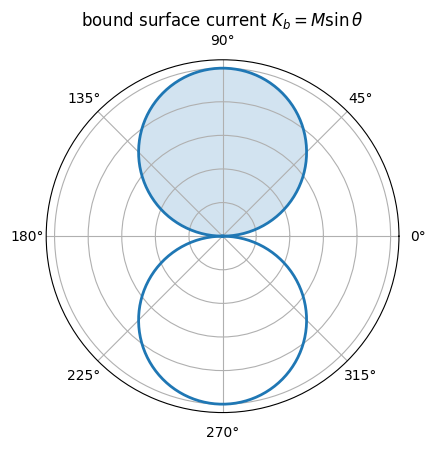

In [9]:
sph = mm.uniformly_magnetized_sphere(M)
display(Math(r"\mathbf B_{\rm in} = " + sp.latex(sph["B_in"]) + r"\,\hat z = \tfrac23\mu_0\mathbf M"))
display(Math(r"\mathbf H_{\rm in} = " + sp.latex(sph["H_in"]) + r"\,\hat z = -\tfrac13\mathbf M"))

# bound surface current K_b = M sin(theta), drawn around the sphere
th = np.linspace(0, np.pi, 100)
plt.figure(figsize=(4.6, 4.6))
ax = plt.subplot(111, projection="polar")
ax.plot(th, np.sin(th), "C0", lw=2); ax.plot(2*np.pi - th, np.sin(th), "C0", lw=2)
ax.fill_between(th, 0, np.sin(th), alpha=0.2)
ax.set_title(r"bound surface current $K_b = M\sin\theta$"); ax.set_yticklabels([])
plt.tight_layout(); plt.show()

## §4 Three kinds of magnetic matter

$\chi_m$ sets the type: **diamagnets** ($\chi_m<0$, faintly repelled — every material, from induced
loops), **paramagnets** ($\chi_m>0$ small, weakly attracted, aligning spins), **ferromagnets**
($\chi_m\sim10^3$$-$$10^5$, nonlinear, *remember* their history — hysteresis). Paramagnetic
susceptibility follows the **Curie law** $\chi_m=C/T$: heat fights alignment.

  chi_m =   -1e-05: diamagnet
  chi_m =   0.0002: paramagnet
  chi_m =     5000: ferromagnet (linear model only approximate -- real ones hysteresis)


<IPython.core.display.Math object>

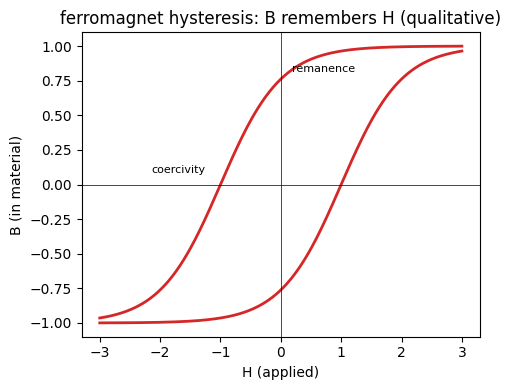

In [10]:
for cm in (-1e-5, 2e-4, 5000):
    print(f"  chi_m = {cm:>8}: {mm.classify_magnetic(cm)}")
C, T = sp.symbols("C T", positive=True)
display(Math(r"\text{Curie law: } \chi_m = " + sp.latex(mm.curie_law(C, T)) + r"\ \ (\text{falls as }1/T)"))

# qualitative hysteresis loop of a ferromagnet (B vs H, with memory)
H = np.linspace(-3, 3, 400)
up = np.tanh(H - 1) + 0.0          # lower branch (increasing H)
dn = np.tanh(H + 1)                # upper branch (decreasing H)
plt.figure(figsize=(5, 4))
plt.plot(H, up, "C3", lw=2); plt.plot(H, dn, "C3", lw=2)
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.annotate("remanence", (0, np.tanh(1)), textcoords="offset points", xytext=(8, 5), fontsize=8)
plt.annotate("coercivity", (-1, 0), textcoords="offset points", xytext=(-50, 8), fontsize=8)
plt.xlabel("H (applied)"); plt.ylabel("B (in material)")
plt.title("ferromagnet hysteresis: B remembers H (qualitative)"); plt.tight_layout(); plt.show()

## §5 The magnetizable sphere — flux concentration

Same Laplace BVP as the dielectric sphere (with $\epsilon_r\to\mu_r$), but read out in both fields:

$$\frac{H_{\rm in}}{H_0}=\frac{3}{\mu_r+2}\quad(\text{reduced, like }E),\qquad
\frac{B_{\rm in}}{B_0}=\frac{3\mu_r}{\mu_r+2}\quad(\text{enhanced}).$$

As $\mu_r\to\infty$ (soft iron, $\mu$-metal) the sphere **sucks in flux**, $B_{\rm in}\to3B_0$, while
expelling $H$ to zero — the principle of magnetic shielding and transformer cores.

<IPython.core.display.Math object>

limits  mu_r->1:  B/B0 = 1  H/H0 = 1
limits  mu_r->oo: B/B0 = 3  H/H0 = 0  (flux concentrated, H expelled)


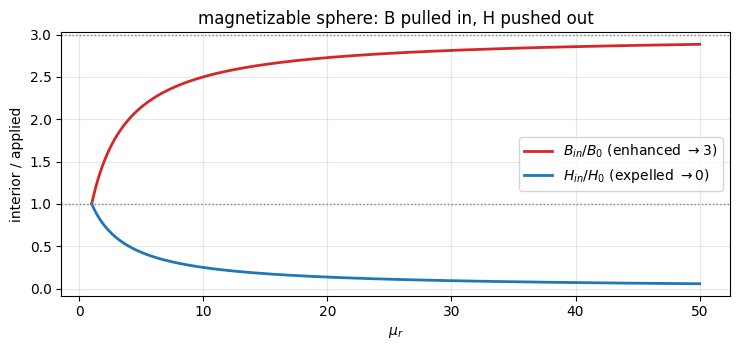

In [8]:
res = mm.magnetizable_sphere_in_field(mu_r, B0)
display(Math(r"\frac{H_{\rm in}}{H_0} = " + sp.latex(res["H_in_over_H0"])
             + r",\qquad \frac{B_{\rm in}}{B_0} = " + sp.latex(res["B_in_over_B0"])))
print("limits  mu_r->1:  B/B0 =", sp.limit(res["B_in_over_B0"], mu_r, 1),
      " H/H0 =", sp.limit(res["H_in_over_H0"], mu_r, 1))
print("limits  mu_r->oo: B/B0 =", sp.limit(res["B_in_over_B0"], mu_r, sp.oo),
      " H/H0 =", sp.limit(res["H_in_over_H0"], mu_r, sp.oo), " (flux concentrated, H expelled)")

mus = np.linspace(1, 50, 300)
plt.figure(figsize=(7.5, 3.6))
plt.plot(mus, 3*mus/(mus+2), "C3", lw=2, label="$B_{in}/B_0$ (enhanced $\\to 3$)")
plt.plot(mus, 3/(mus+2), "C0", lw=2, label="$H_{in}/H_0$ (expelled $\\to 0$)")
plt.axhline(3, color="gray", ls=":", lw=1); plt.axhline(1, color="gray", ls=":", lw=1)
plt.xlabel(r"$\mu_r$"); plt.ylabel("interior / applied"); plt.legend()
plt.title("magnetizable sphere: B pulled in, H pushed out"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §6 Where this lands

- **E/D/P $\leftrightarrow$ B/H/M is a true duality** — every Ch. 4 result has a Ch. 6 twin under
  $\mathbf P\to\mathbf M$, $\mathbf E\to\mathbf H$, $\epsilon\to\mu$. The dielectric and magnetizable
  spheres are the *same* Laplace BVP; only the field you read out differs.
- **Flux concentration runs the hardware** — transformer cores, inductors, MRI magnets, and $\mu$-metal
  shielding all exploit $\mu_r\gg1$ pulling $B$ in. The same shielding logic protects the sensitive
  photodetectors in this repo's optical front end from stray fields.
- **$\epsilon$ and $\mu$ make the optics.** The refractive index is $n=\sqrt{\epsilon_r\mu_r}$ and the
  wave impedance $\sqrt{\mu/\epsilon}$ — the constants from Ch. 4 and Ch. 6 together set how light
  propagates in the fibre the TD-GS pipeline uses. And $\nabla\times\mathbf H=\mathbf J$ joins the
  other three Maxwell equations; the boost that mixes $\mathbf E$ and $\mathbf B$ is the rapidity
  machinery from PS#1.

Engine added this session: `griffiths/magnetic_matter.py` (magnetization, bound currents, H field,
linear media + Curie law, the two BVPs), benchmarked in `scripts/smoke_magnetic_matter.py` (incl. the
exact dielectric duality). The `griffiths` package now spans Griffiths Ch. 1-6.